## Importing the relevant packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima_model import ARIMA
from scipy.stats.distributions import chi2 
from math import sqrt
import seaborn as sns
sns.set()

## Importing the Data and Pre-processing 

In [3]:
raw_csv_data = pd.read_csv("./../../Section 3/S_3_L_11/Index2018.csv") 
df_comp=raw_csv_data.copy()
df_comp.date = pd.to_datetime(df_comp.date, dayfirst = True)
df_comp.set_index("date", inplace=True)
df_comp=df_comp.asfreq('b')
df_comp=df_comp.fillna(method='ffill')

C:\Users\Cesar\AppData\Local\Temp\ipykernel_14584\3874627497.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_comp=df_comp.fillna(method='ffill')


In [4]:
df_comp['market_value']=df_comp.ftse

In [5]:
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]

In [6]:
import warnings
warnings.filterwarnings("ignore")

## The LLR Test

In [7]:
def LLR_test(mod_1, mod_2, DF = 1):
    L1 = mod_1.fit(start_ar_lags = 11).llf
    L2 = mod_2.fit(start_ar_lags = 11).llf
    LR = (2*(L2-L1))    
    p = chi2.sf(LR, DF).round(3)
    return p

## Creating Returns

In [8]:
df['returns'] = df.market_value.pct_change(1)*100

## Creating Squared Returns

In [9]:
df['sq_returns'] = df.returns.mul(df.returns)

## Returns vs Squared Returns

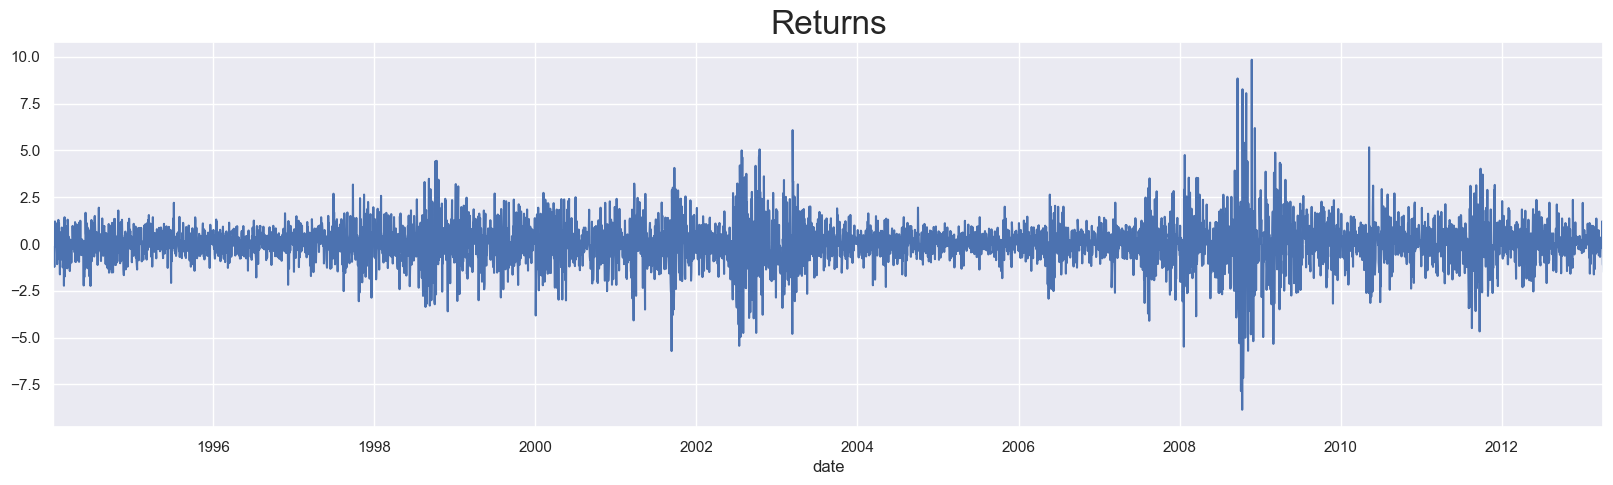

In [10]:
df.returns.plot(figsize=(20,5))
plt.title("Returns", size = 24)
plt.show()

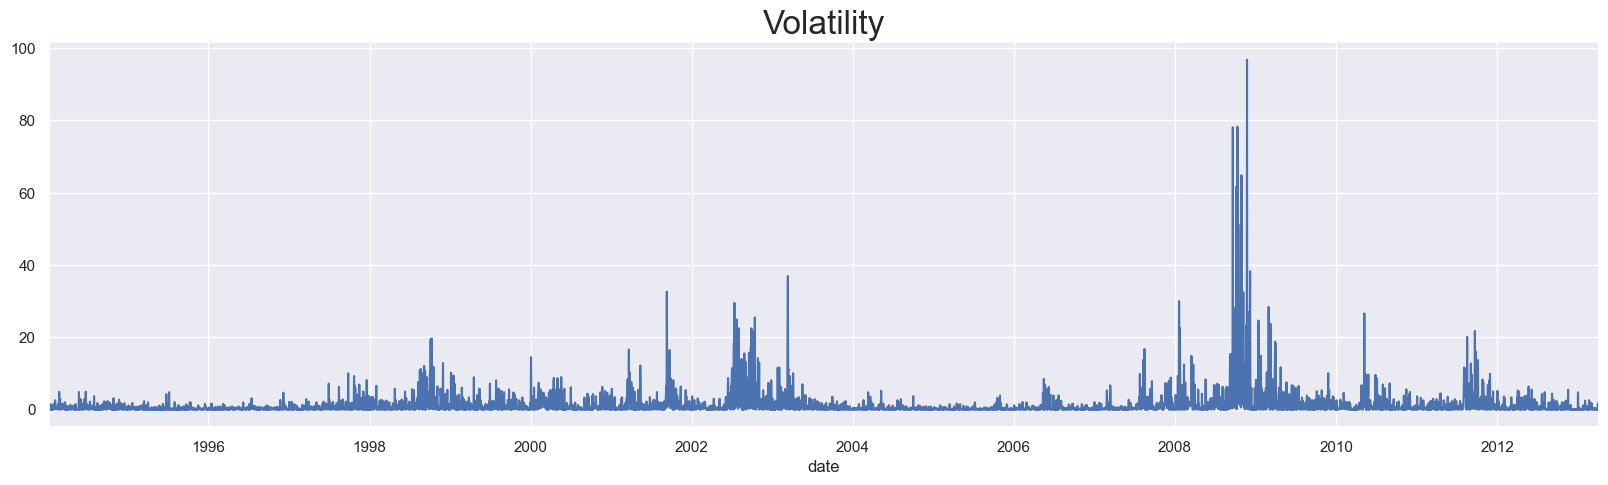

In [11]:
df.sq_returns.plot(figsize=(20,5))
plt.title("Volatility", size = 24)
plt.show()

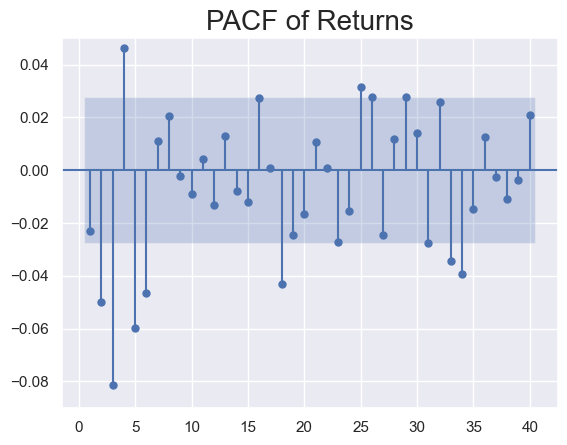

In [13]:
sgt.plot_pacf(df.returns[1:], lags = 40, alpha = 0.05, zero = False , method = ('ols'))
plt.title("PACF of Returns", size = 20)
plt.ylim(-0.09,0.05)
plt.show()

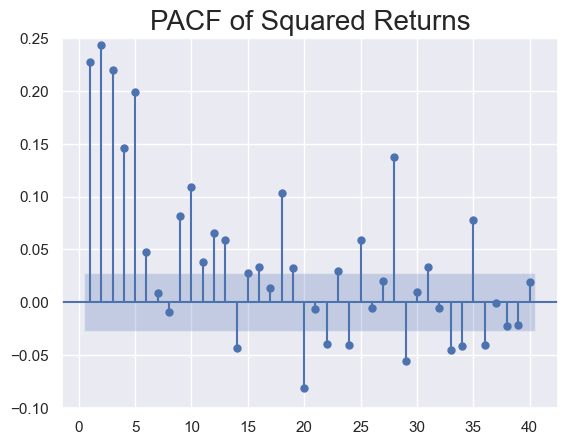

In [15]:
sgt.plot_pacf(df.sq_returns[1:], lags = 40, alpha = 0.05, zero = False , method = ('ols'))
plt.title("PACF of Squared Returns", size = 20)
plt.ylim(-0.1,0.25)
plt.show()

## The arch_model() Method

In [16]:
from arch import arch_model

In [17]:
model_arch_1 = arch_model(df.returns[1:])
results_arch_1 = model_arch_1.fit()
results_arch_1.summary()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 29094651266.161934
Iteration:      2,   Func. Count:     15,   Neg. LLF: 2701100875.2098923
Iteration:      3,   Func. Count:     23,   Neg. LLF: 7009.030699853345
Iteration:      4,   Func. Count:     29,   Neg. LLF: 7024.0359100394935
Iteration:      5,   Func. Count:     35,   Neg. LLF: 7010.712831785119
Iteration:      6,   Func. Count:     41,   Neg. LLF: 6975.4180672558305
Iteration:      7,   Func. Count:     47,   Neg. LLF: 7092.264204435633
Iteration:      8,   Func. Count:     53,   Neg. LLF: 6973.879231562698
Iteration:      9,   Func. Count:     59,   Neg. LLF: 6970.088049529862
Iteration:     10,   Func. Count:     64,   Neg. LLF: 6970.05847841905
Iteration:     11,   Func. Count:     69,   Neg. LLF: 6970.058367475096
Iteration:     12,   Func. Count:     74,   Neg. LLF: 6970.058366189902
Iteration:     13,   Func. Count:     78,   Neg. LLF: 6970.058366189187
Optimization terminated successfully    (Exit mode 0)
       

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6970.06
Distribution:                  Normal   AIC:                           13948.1
Method:            Maximum Likelihood   BIC:                           13974.2
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        22:53:55   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0466  1.183e-02      3.939  8.187e-05 [2.342e-02,6.981e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0109  3.004e-03      3.640  2.724e-04 [5.048e-03,1.682e-02]
alpha[1]       0.0835  1.071e-02      7.794  6.476e-15   [6.249e-02,  0.104]
beta[1]        0.9089  1.148e-02     79.168      0.000     [  0.886,  0.931]
============================================================================

Covariance estimator: robust
"""

In [18]:
model_arch_1 = arch_model(df.returns[1:])
results_arch_1 = model_arch_1.fit(update_freq = 5)
results_arch_1.summary()

Iteration:      5,   Func. Count:     35,   Neg. LLF: 7010.712831785119
Iteration:     10,   Func. Count:     64,   Neg. LLF: 6970.05847841905
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6970.058366189902
            Iterations: 13
            Function evaluations: 78
            Gradient evaluations: 13


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6970.06
Distribution:                  Normal   AIC:                           13948.1
Method:            Maximum Likelihood   BIC:                           13974.2
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        22:54:02   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0466  1.183e-02      3.939  8.187e-05 [2.342e-02,6.981e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0109  3.004e-03      3.640  2.724e-04 [5.048e-03,1.682e-02]
alpha[1]       0.0835  1.071e-02      7.794  6.476e-15   [6.249e-02,  0.104]
beta[1]        0.9089  1.148e-02     79.168      0.000     [  0.886,  0.931]
============================================================================

Covariance estimator: robust
"""

## The Simple ARCH(1) 

In [19]:
model_arch_1 = arch_model(df.returns[1:], mean = "Constant", vol = "ARCH", p = 1)
results_arch_1 = model_arch_1.fit(update_freq = 5)
results_arch_1.summary()

Iteration:      5,   Func. Count:     30,   Neg. LLF: 7660.0887820409735
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7660.0887820409735
            Iterations: 6
            Function evaluations: 33
            Gradient evaluations: 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -7660.09
Distribution:                  Normal   AIC:                           15326.2
Method:            Maximum Likelihood   BIC:                           15345.7
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        22:54:54   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0345  1.603e-02      2.151  3.147e-02 [3.063e-03,6.590e-02]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0.9206  4.309e-02     21.365 2.855e-101 [  0.836,  1.005]
alpha[1]       0.3684  5.040e-02      7.310  2.673e-13 [  0.270,  0.467]
========================================================================

Covariance estimator: robust
"""

All 3 coefficients turn out to be significant.  
The Log-Likelihood is higher than that of any of the ARIMAX family we showed.  
However, it is crucial to remember that the arch can only be used to predict future variance rather than future returns

In [ ]:
model_arch_12 = arch_model(df.returns[1:], mean = "AR", lags=[2, 3, 6], vol = "ARCH", p = 1, dist="t") # , dist="ged"
results_arch_12 = model_arch_12.fit(update_freq = 5)
results_arch_12.summary()

Iteration:      5,   Func. Count:     54,   Neg. LLF: 99272.06862463368
Iteration:     10,   Func. Count:    101,   Neg. LLF: 7329.094427103053
Iteration:     15,   Func. Count:    141,   Neg. LLF: 7327.763601270755
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7327.763601270755
            Iterations: 16
            Function evaluations: 148
            Gradient evaluations: 16


<class 'statsmodels.iolib.summary.Summary'>
"""
                              AR - ARCH Model Results                               
====================================================================================
Dep. Variable:                      returns   R-squared:                       0.007
Mean Model:                              AR   Adj. R-squared:                  0.007
Vol Model:                             ARCH   Log-Likelihood:               -7327.76
Distribution:      Standardized Student's t   AIC:                           14669.5
Method:                  Maximum Likelihood   BIC:                           14715.2
                                              No. Observations:                 5014
Date:                      Sat, Jan 17 2026   Df Residuals:                     5010
Time:                              23:12:04   Df Model:                            4
                                  Mean Model                                  
==============================================================================
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
Const          0.0554  1.323e-02      4.189  2.802e-05   [2.948e-02,8.134e-02]
returns[2]    -0.0310  1.834e-02     -1.690  9.109e-02  [-6.693e-02,4.957e-03]
returns[3]    -0.0336  1.859e-02     -1.806  7.093e-02  [-7.001e-02,2.864e-03]
returns[6]    -0.0417  1.877e-02     -2.221  2.638e-02 [-7.845e-02,-4.891e-03]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          1.0033  5.052e-02     19.859  9.216e-88 [  0.904,  1.102]
alpha[1]       0.3585  4.144e-02      8.652  5.058e-18 [  0.277,  0.440]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             3.8083      0.217     17.556  5.399e-69 [  3.383,  4.233]
========================================================================

Covariance estimator: robust
"""

In [21]:
model_arch_13 = arch_model(df.returns[1:], mean = "Zero", vol = "ARCH", p = 1)
results_arch_13 = model_arch_13.fit(update_freq = 5)
results_arch_13.summary()

Iteration:      5,   Func. Count:     20,   Neg. LLF: 7662.934731760508
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7662.934731760495
            Iterations: 5
            Function evaluations: 20
            Gradient evaluations: 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                        Zero Mean - ARCH Model Results                        
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -7662.93
Distribution:                  Normal   AIC:                           15329.9
Method:            Maximum Likelihood   BIC:                           15342.9
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5020
Time:                        23:10:59   Df Model:                            0
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0.9244  4.332e-02     21.340 4.808e-101 [  0.839,  1.009]
alpha[1]       0.3640  4.945e-02      7.361  1.825e-13 [  0.267,  0.461]
========================================================================

Covariance estimator: robust
"""

## Higher-Lag ARCH Models

In [23]:
model_arch_2 = arch_model(df.returns[1:], mean = "Constant", vol = "ARCH", p = 2)
results_arch_2 = model_arch_2.fit(update_freq = 5)
results_arch_2.summary()

Iteration:      5,   Func. Count:     37,   Neg. LLF: 8810.00758561911
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7449.545164097792
            Iterations: 9
            Function evaluations: 58
            Gradient evaluations: 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -7449.55
Distribution:                  Normal   AIC:                           14907.1
Method:            Maximum Likelihood   BIC:                           14933.2
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        23:21:26   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0484  1.401e-02      3.455  5.495e-04 [2.095e-02,7.585e-02]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0.6978  3.564e-02     19.580  2.272e-85 [  0.628,  0.768]
alpha[1]       0.2202  3.474e-02      6.339  2.311e-10 [  0.152,  0.288]
alpha[2]       0.2783  3.645e-02      7.635  2.260e-14 [  0.207,  0.350]
========================================================================

Covariance estimator: robust
"""

In [24]:
model_arch_3 = arch_model(df.returns[1:], mean = "Constant", vol = "ARCH", p = 3)
results_arch_3 = model_arch_3.fit(update_freq = 5)
results_arch_3.summary()

Iteration:      5,   Func. Count:     41,   Neg. LLF: 7496.407402540585
Iteration:     10,   Func. Count:     75,   Neg. LLF: 7277.050452148393
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7277.050452148393
            Iterations: 11
            Function evaluations: 80
            Gradient evaluations: 11


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -7277.05
Distribution:                  Normal   AIC:                           14564.1
Method:            Maximum Likelihood   BIC:                           14596.7
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        23:21:54   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0529  1.316e-02      4.018  5.875e-05 [2.707e-02,7.865e-02]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0.5012  2.834e-02     17.685  5.505e-70 [  0.446,  0.557]
alpha[1]       0.1570  2.649e-02      5.926  3.108e-09 [  0.105,  0.209]
alpha[2]       0.2197  2.588e-02      8.489  2.077e-17 [  0.169,  0.270]
alpha[3]       0.2804  3.354e-02      8.359  6.302e-17 [  0.215,  0.346]
========================================================================

Covariance estimator: robust
"""

In [25]:
model_arch_4 = arch_model(df.returns[1:], mean = "Constant", vol = "ARCH", p = 4)
results_arch_4 = model_arch_4.fit(update_freq = 5)
results_arch_4.summary()

Iteration:      5,   Func. Count:     46,   Neg. LLF: 7924.331258597425
Iteration:     10,   Func. Count:     89,   Neg. LLF: 7183.85130280025
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7183.851092095116
            Iterations: 13
            Function evaluations: 109
            Gradient evaluations: 13


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -7183.85
Distribution:                  Normal   AIC:                           14379.7
Method:            Maximum Likelihood   BIC:                           14418.8
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        23:22:16   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0583  1.267e-02      4.602  4.191e-06 [3.347e-02,8.314e-02]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.3928  2.490e-02     15.774  4.701e-56   [  0.344,  0.442]
alpha[1]       0.1375  2.504e-02      5.492  3.980e-08 [8.844e-02,  0.187]
alpha[2]       0.1970  2.404e-02      8.194  2.526e-16   [  0.150,  0.244]
alpha[3]       0.2289  2.912e-02      7.861  3.811e-15   [  0.172,  0.286]
alpha[4]       0.1793  2.342e-02      7.655  1.935e-14   [  0.133,  0.225]
==========================================================================

Covariance estimator: robust
"""

In [26]:
model_arch_5 = arch_model(df.returns[1:], mean = "Constant", vol = "ARCH", p = 5)
results_arch_5 = model_arch_5.fit(update_freq = 5)
results_arch_5.summary()

Iteration:      5,   Func. Count:     53,   Neg. LLF: 7495.0776078247745
Iteration:     10,   Func. Count:    102,   Neg. LLF: 7111.886055607627
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7111.88433420655
            Iterations: 13
            Function evaluations: 126
            Gradient evaluations: 13


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -7111.88
Distribution:                  Normal   AIC:                           14237.8
Method:            Maximum Likelihood   BIC:                           14283.4
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        23:23:41   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0562  1.225e-02      4.585  4.545e-06 [3.216e-02,8.020e-02]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.3429  2.374e-02     14.445  2.677e-47   [  0.296,  0.389]
alpha[1]       0.1053  2.119e-02      4.967  6.812e-07 [6.373e-02,  0.147]
alpha[2]       0.1726  2.216e-02      7.788  6.813e-15   [  0.129,  0.216]
alpha[3]       0.1780  2.547e-02      6.989  2.766e-12   [  0.128,  0.228]
alpha[4]       0.1604  2.199e-02      7.293  3.036e-13   [  0.117,  0.203]
alpha[5]       0.1444  2.096e-02      6.887  5.678e-12   [  0.103,  0.185]
==========================================================================

Covariance estimator: robust
"""

In [27]:
model_arch_6 = arch_model(df.returns[1:], mean = "Constant", vol = "ARCH", p = 6)
results_arch_6 = model_arch_6.fit(update_freq = 5)
results_arch_6.summary()

Iteration:      5,   Func. Count:     58,   Neg. LLF: 7484.2259005108135
Iteration:     10,   Func. Count:    110,   Neg. LLF: 7304.869082758109
Iteration:     15,   Func. Count:    159,   Neg. LLF: 7059.614680278564
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7059.614680278564
            Iterations: 16
            Function evaluations: 167
            Gradient evaluations: 16


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -7059.61
Distribution:                  Normal   AIC:                           14135.2
Method:            Maximum Likelihood   BIC:                           14187.4
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        23:24:20   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0555  1.201e-02      4.627  3.718e-06 [3.202e-02,7.908e-02]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.2881  2.311e-02     12.469  1.097e-35   [  0.243,  0.333]
alpha[1]       0.0787  1.876e-02      4.193  2.754e-05 [4.189e-02,  0.115]
alpha[2]       0.1425  2.032e-02      7.011  2.362e-12   [  0.103,  0.182]
alpha[3]       0.1743  2.674e-02      6.517  7.157e-11   [  0.122,  0.227]
alpha[4]       0.1357  2.142e-02      6.336  2.356e-10 [9.375e-02,  0.178]
alpha[5]       0.1387  2.045e-02      6.783  1.180e-11 [9.862e-02,  0.179]
alpha[6]       0.1354  2.025e-02      6.688  2.261e-11 [9.574e-02,  0.175]
==========================================================================

Covariance estimator: robust
"""

In [28]:
model_arch_7 = arch_model(df.returns[1:], mean = "Constant", vol = "ARCH", p = 7)
results_arch_7 = model_arch_7.fit(update_freq = 5)
results_arch_7.summary()

Iteration:      5,   Func. Count:     63,   Neg. LLF: 8245.8490465992
Iteration:     10,   Func. Count:    122,   Neg. LLF: 7454.0326815473245
Iteration:     15,   Func. Count:    179,   Neg. LLF: 7042.934821569989
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7042.934820004489
            Iterations: 17
            Function evaluations: 198
            Gradient evaluations: 17


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -7042.93
Distribution:                  Normal   AIC:                           14103.9
Method:            Maximum Likelihood   BIC:                           14162.6
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        23:24:46   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0576  1.185e-02      4.863  1.154e-06 [3.442e-02,8.088e-02]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.2628  2.278e-02     11.537  8.598e-31   [  0.218,  0.307]
alpha[1]       0.0678  1.766e-02      3.837  1.247e-04 [3.314e-02,  0.102]
alpha[2]       0.1334  2.015e-02      6.620  3.589e-11 [9.391e-02,  0.173]
alpha[3]       0.1642  2.742e-02      5.987  2.137e-09   [  0.110,  0.218]
alpha[4]       0.1182  2.171e-02      5.443  5.228e-08 [7.564e-02,  0.161]
alpha[5]       0.1308  1.955e-02      6.690  2.229e-11 [9.248e-02,  0.169]
alpha[6]       0.1305  1.991e-02      6.554  5.613e-11 [9.146e-02,  0.170]
alpha[7]       0.0806  2.061e-02      3.912  9.169e-05 [4.023e-02,  0.121]
==========================================================================

Covariance estimator: robust
"""

In [29]:
model_arch_8 = arch_model(df.returns[1:], mean = "Constant", vol = "ARCH", p = 8)
results_arch_8 = model_arch_8.fit(update_freq = 5)
results_arch_8.summary()

Iteration:      5,   Func. Count:     66,   Neg. LLF: 17007.393212422066
Iteration:     10,   Func. Count:    130,   Neg. LLF: 7408.467653598271
Iteration:     15,   Func. Count:    195,   Neg. LLF: 7030.7288270875215
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7026.052162397099
            Iterations: 19
            Function evaluations: 240
            Gradient evaluations: 19


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -7026.05
Distribution:                  Normal   AIC:                           14072.1
Method:            Maximum Likelihood   BIC:                           14137.3
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        23:25:08   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0551  1.174e-02      4.694  2.677e-06 [3.210e-02,7.813e-02]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.2428  2.244e-02     10.820  2.761e-27   [  0.199,  0.287]
alpha[1]       0.0709  1.836e-02      3.862  1.125e-04 [3.493e-02,  0.107]
alpha[2]       0.1275  2.006e-02      6.357  2.051e-10 [8.820e-02,  0.167]
alpha[3]       0.1481  2.652e-02      5.585  2.337e-08 [9.615e-02,  0.200]
alpha[4]       0.1127  2.162e-02      5.214  1.851e-07 [7.034e-02,  0.155]
alpha[5]       0.1164  1.887e-02      6.168  6.925e-10 [7.942e-02,  0.153]
alpha[6]       0.1219  1.971e-02      6.183  6.289e-10 [8.324e-02,  0.161]
alpha[7]       0.0702  1.986e-02      3.534  4.091e-04 [3.127e-02,  0.109]
alpha[8]       0.0704  1.746e-02      4.031  5.549e-05 [3.617e-02,  0.105]
==========================================================================

Covariance estimator: robust
"""

In [30]:
model_arch_9 = arch_model(df.returns[1:], mean = "Constant", vol = "ARCH", p = 9)
results_arch_9 = model_arch_9.fit(update_freq = 5)
results_arch_9.summary()

Iteration:      5,   Func. Count:     72,   Neg. LLF: 8851.601869376398
Iteration:     10,   Func. Count:    141,   Neg. LLF: 7339.520395905388
Iteration:     15,   Func. Count:    210,   Neg. LLF: 7080.030411984868
Iteration:     20,   Func. Count:    275,   Neg. LLF: 7020.011491318955
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7020.011491318955
            Iterations: 21
            Function evaluations: 286
            Gradient evaluations: 21


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -7020.01
Distribution:                  Normal   AIC:                           14062.0
Method:            Maximum Likelihood   BIC:                           14133.8
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        23:25:29   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0541  1.185e-02      4.567  4.946e-06 [3.089e-02,7.734e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.2342  2.262e-02     10.353  4.036e-25     [  0.190,  0.279]
alpha[1]       0.0701  1.813e-02      3.865  1.109e-04   [3.455e-02,  0.106]
alpha[2]       0.1238  1.993e-02      6.214  5.172e-10   [8.478e-02,  0.163]
alpha[3]       0.1438  2.629e-02      5.469  4.521e-08   [9.226e-02,  0.195]
alpha[4]       0.1060  2.175e-02      4.874  1.095e-06   [6.337e-02,  0.149]
alpha[5]       0.1061  1.903e-02      5.578  2.437e-08   [6.883e-02,  0.143]
alpha[6]       0.1131  1.986e-02      5.694  1.240e-08   [7.417e-02,  0.152]
alpha[7]       0.0622  1.929e-02      3.224  1.265e-03   [2.439e-02,  0.100]
alpha[8]       0.0719  1.759e-02      4.087  4.379e-05   [3.740e-02,  0.106]
alpha[9]       0.0446  1.690e-02      2.637  8.369e-03 [1.144e-02,7.768e-02]
============================================================================

Covariance estimator: robust
"""

In [31]:
model_arch_10 = arch_model(df.returns[1:], mean = "Constant", vol = "ARCH", p = 10)
results_arch_10 = model_arch_10.fit(update_freq = 5)
results_arch_10.summary()

Iteration:      5,   Func. Count:     77,   Neg. LLF: 8514.522227827503
Iteration:     10,   Func. Count:    152,   Neg. LLF: 8582.966056108853
Iteration:     15,   Func. Count:    226,   Neg. LLF: 7037.580367011822
Iteration:     20,   Func. Count:    296,   Neg. LLF: 7011.983291382586
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7011.983291382586
            Iterations: 21
            Function evaluations: 308
            Gradient evaluations: 21


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -7011.98
Distribution:                  Normal   AIC:                           14048.0
Method:            Maximum Likelihood   BIC:                           14126.2
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        23:25:53   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0522  1.189e-02      4.391  1.130e-05 [2.890e-02,7.552e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.2201  2.228e-02      9.879  5.111e-23     [  0.176,  0.264]
alpha[1]       0.0691  1.786e-02      3.869  1.091e-04   [3.410e-02,  0.104]
alpha[2]       0.1205  2.036e-02      5.916  3.299e-09   [8.056e-02,  0.160]
alpha[3]       0.1420  2.670e-02      5.318  1.050e-07   [8.965e-02,  0.194]
alpha[4]       0.1025  2.219e-02      4.621  3.823e-06   [5.904e-02,  0.146]
alpha[5]       0.0937  1.913e-02      4.901  9.556e-07   [5.625e-02,  0.131]
alpha[6]       0.1069  2.014e-02      5.307  1.117e-07   [6.739e-02,  0.146]
alpha[7]       0.0599  1.919e-02      3.119  1.815e-03 [2.224e-02,9.746e-02]
alpha[8]       0.0702  1.752e-02      4.005  6.195e-05   [3.583e-02,  0.104]
alpha[9]       0.0416  1.648e-02      2.523  1.165e-02 [9.272e-03,7.387e-02]
alpha[10]      0.0466  1.506e-02      3.098  1.948e-03 [1.714e-02,7.616e-02]
============================================================================

Covariance estimator: robust
"""

In [32]:
model_arch_11 = arch_model(df.returns[1:], mean = "Constant", vol = "ARCH", p = 11)
results_arch_11 = model_arch_11.fit(update_freq = 5)
results_arch_11.summary()

Iteration:      5,   Func. Count:     80,   Neg. LLF: 333603.1492755028
Iteration:     10,   Func. Count:    160,   Neg. LLF: 8162.647250150746
Iteration:     15,   Func. Count:    240,   Neg. LLF: 7133.805743732992
Iteration:     20,   Func. Count:    318,   Neg. LLF: 6994.99030023478
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6994.980111027366
            Iterations: 24
            Function evaluations: 375
            Gradient evaluations: 24


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -6994.98
Distribution:                  Normal   AIC:                           14016.0
Method:            Maximum Likelihood   BIC:                           14100.7
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        23:26:26   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0503  1.197e-02      4.199  2.681e-05 [2.680e-02,7.371e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.2042  2.192e-02      9.318  1.191e-20     [  0.161,  0.247]
alpha[1]       0.0640  1.770e-02      3.613  3.025e-04 [2.926e-02,9.864e-02]
alpha[2]       0.1173  2.027e-02      5.787  7.150e-09   [7.757e-02,  0.157]
alpha[3]       0.1361  2.696e-02      5.049  4.442e-07   [8.328e-02,  0.189]
alpha[4]       0.0934  2.114e-02      4.418  9.955e-06   [5.196e-02,  0.135]
alpha[5]       0.0746  1.771e-02      4.214  2.513e-05   [3.991e-02,  0.109]
alpha[6]       0.0931  1.928e-02      4.828  1.382e-06   [5.528e-02,  0.131]
alpha[7]       0.0509  1.858e-02      2.739  6.164e-03 [1.447e-02,8.730e-02]
alpha[8]       0.0688  1.777e-02      3.872  1.080e-04   [3.397e-02,  0.104]
alpha[9]       0.0382  1.578e-02      2.422  1.542e-02 [7.294e-03,6.915e-02]
alpha[10]      0.0479  1.505e-02      3.180  1.473e-03 [1.837e-02,7.738e-02]
alpha[11]      0.0773  1.739e-02      4.447  8.701e-06   [4.326e-02,  0.111]
============================================================================

Covariance estimator: robust
"""

In [33]:
model_arch_12 = arch_model(df.returns[1:], mean = "Constant", vol = "ARCH", p = 12)
results_arch_12 = model_arch_12.fit(update_freq = 5)
results_arch_12.summary()

Iteration:      5,   Func. Count:     86,   Neg. LLF: 9557.46156246595
Iteration:     10,   Func. Count:    171,   Neg. LLF: 7694.211595675921
Iteration:     15,   Func. Count:    256,   Neg. LLF: 7343.8453129097115
Iteration:     20,   Func. Count:    340,   Neg. LLF: 7021.706318596702
Iteration:     25,   Func. Count:    418,   Neg. LLF: 6988.5135817731
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6988.5135817731
            Iterations: 26
            Function evaluations: 432
            Gradient evaluations: 26


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -6988.51
Distribution:                  Normal   AIC:                           14005.0
Method:            Maximum Likelihood   BIC:                           14096.3
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        23:26:55   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0496  1.201e-02      4.130  3.624e-05 [2.607e-02,7.315e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.1946  2.181e-02      8.923  4.558e-19     [  0.152,  0.237]
alpha[1]       0.0567  1.725e-02      3.290  1.002e-03 [2.294e-02,9.054e-02]
alpha[2]       0.1159  1.983e-02      5.846  5.049e-09   [7.707e-02,  0.155]
alpha[3]       0.1306  2.629e-02      4.967  6.790e-07   [7.908e-02,  0.182]
alpha[4]       0.0902  2.140e-02      4.215  2.498e-05   [4.826e-02,  0.132]
alpha[5]       0.0740  1.759e-02      4.209  2.560e-05   [3.956e-02,  0.108]
alpha[6]       0.0907  1.913e-02      4.741  2.128e-06   [5.319e-02,  0.128]
alpha[7]       0.0468  1.787e-02      2.617  8.875e-03 [1.174e-02,8.180e-02]
alpha[8]       0.0662  1.793e-02      3.692  2.221e-04   [3.106e-02,  0.101]
alpha[9]       0.0342  1.606e-02      2.131  3.309e-02 [2.748e-03,6.570e-02]
alpha[10]      0.0370  1.567e-02      2.363  1.814e-02 [6.311e-03,6.772e-02]
alpha[11]      0.0780  1.752e-02      4.454  8.429e-06   [4.370e-02,  0.112]
alpha[12]      0.0480  1.844e-02      2.604  9.202e-03 [1.189e-02,8.418e-02]
============================================================================

Covariance estimator: robust
"""

In [34]:
model_arch_13 = arch_model(df.returns[1:], mean = "Constant", vol = "ARCH", p = 13)
results_arch_13 = model_arch_13.fit(update_freq = 5)
results_arch_13.summary()

Iteration:      5,   Func. Count:     89,   Neg. LLF: 10011.778943092455
Iteration:     10,   Func. Count:    179,   Neg. LLF: 7471.003079075868
Iteration:     15,   Func. Count:    269,   Neg. LLF: 7087.927420783266
Iteration:     20,   Func. Count:    359,   Neg. LLF: 7063.560541392564
Iteration:     25,   Func. Count:    444,   Neg. LLF: 6984.175063790553
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6984.175062618497
            Iterations: 27
            Function evaluations: 475
            Gradient evaluations: 27


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -6984.18
Distribution:                  Normal   AIC:                           13998.4
Method:            Maximum Likelihood   BIC:                           14096.2
                                        No. Observations:                 5020
Date:                Sat, Jan 17 2026   Df Residuals:                     5019
Time:                        23:27:27   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0492  1.206e-02      4.077  4.566e-05 [2.553e-02,7.281e-02]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.1871  2.210e-02      8.466  2.538e-17      [  0.144,  0.230]
alpha[1]       0.0568  1.729e-02      3.282  1.029e-03  [2.287e-02,9.065e-02]
alpha[2]       0.1156  2.017e-02      5.733  9.841e-09    [7.610e-02,  0.155]
alpha[3]       0.1265  2.625e-02      4.820  1.433e-06    [7.509e-02,  0.178]
alpha[4]       0.0884  2.159e-02      4.093  4.265e-05    [4.605e-02,  0.131]
alpha[5]       0.0695  1.750e-02      3.970  7.189e-05    [3.518e-02,  0.104]
alpha[6]       0.0865  1.926e-02      4.491  7.092e-06    [4.874e-02,  0.124]
alpha[7]       0.0404  1.846e-02      2.188  2.870e-02  [4.203e-03,7.658e-02]
alpha[8]       0.0654  1.833e-02      3.565  3.633e-04    [2.943e-02,  0.101]
alpha[9]       0.0292  1.603e-02      1.820  6.877e-02 [-2.245e-03,6.058e-02]
alpha[10]      0.0335  1.605e-02      2.089  3.670e-02  [2.072e-03,6.498e-02]
alpha[11]      0.0775  1.760e-02      4.403  1.067e-05    [4.300e-02,  0.112]
alpha[12]      0.0473  1.873e-02      2.526  1.153e-02  [1.060e-02,8.402e-02]
alpha[13]      0.0372  1.431e-02      2.600  9.318e-03  [9.162e-03,6.526e-02]
=============================================================================

Covariance estimator: robust
"""

Looking for a better model we found that the 12 model was the optimal because the 13 has a alpha[9] which is not significant